# WEC Dynamic Simulation with PSS/E

**Author:** WEC-GRID Research Team  
**Date:** November 2025  
**Purpose:** Dynamic simulation of Wave Energy Converter (WEC) power injection into a transmission grid

---

## Overview

This notebook demonstrates **time-domain dynamic simulation** of WEC farm power injection using PSS/E's transient stability analysis capabilities. Unlike steady-state power flow analysis, dynamic simulation captures the temporal evolution of grid frequency and voltage in response to variable renewable generation.

### Methodology

Based on the NREL co-simulation framework:
- **Paper:** [Grid Integration of Marine Energy](https://docs.nrel.gov/docs/fy25osti/91114.pdf)
- **Reference Code:** `cpds_cosim/machine_1/Transmission/TransmissionSim.py`

### Key Technical Approach

| Aspect | Steady-State (`fnsl`) | Dynamic (`strt_2` + `run`) |
|--------|----------------------|---------------------------|
| Solution Method | Power balance equations | Differential-algebraic equations |
| Time Resolution | Single snapshot | Continuous time-stepping |
| Frequency | Assumed constant (60 Hz) | Calculated from generator dynamics |
| Generator Models | PQ/PV injection | Full swing equation, governors, exciters |
| Use Case | Planning studies | Transient stability, frequency response |

### Simulation Workflow

1. **Load WEC Power Data** - Time-series from WECGrid database (WEC-Sim output)
2. **Initialize Grid Model** - IEEE 14-bus with reduced inertia dynamic models
3. **Dynamic Initialization** - `psspy.strt_2()` with snapshot file (.snp)
4. **Time-Stepping Loop** - Inject WEC power as negative load, advance with `psspy.run()`
5. **Post-Processing** - Extract voltage/frequency from output channels

---

## 1. Environment Setup and PSS/E Initialization

Initialize the PSS/E Python environment and import required libraries for:
- **PSS/E API** (`psspy`) - Power system simulation
- **dyntools** - Dynamic simulation output processing
- **pandas/numpy** - Data manipulation
- **matplotlib** - Visualization

In [1]:
# Import required libraries
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import sys

# Initialize PSS/E
import pssepath
pssepath.add_pssepath()

import psse35
import psspy
import dyntools

psse35.set_minor(3)
psspy.psseinit(1000)

print("PSS/E initialized successfully!")

    Sets PSSE environment to latest minor version among installed versions of PSSE 35.
    Use psse35.set_minor(n) to set PSSE35 minor version (n) to use.
        Example, for PSSE 35.0.x, use this as: psse35.set_minor(0)

 PSS(R)E Xplore Version 35
 Copyright (c) 1976-2025
 Siemens Industry, Inc.,
 Power Technologies International                            (PTI)
 This program is a confidential  unpublished  work  created  and  first
 licensed in 1976.  It is a trade secret which is the property of  PTI.
 All use,  disclosure,  and/or reproduction not specifically authorized
 by  PTI  is prohibited.   This  program is protected  under  copyright
 laws  of  non-U.S.  countries  and  by  application  of  international
 treaties.  All  Rights  Reserved  Under  The  Copyright  Laws.

 Could not find entry point runpy_add_to_sys_path

           SIEMENS POWER TECHNOLOGIES INTERNATIONAL

    50 BUS POWER SYSTEM SIMULATOR--PSS(R)E Xplore-35.5.2

             INITIATED ON TUE, NOV 25 2025  15

---

## 2. WEC Power Data Acquisition

Load WEC power time-series from the WECGrid SQLite database. The data originates from WEC-Sim hydrodynamic simulations of the **RM3 (Reference Model 3)** point absorber device.

**RM3 Device Specifications:**
- Two-body point absorber (float + spar/plate)
- Rated power: ~30-50 kW per device
- Capture width ratio: ~0.3-0.5

In [2]:
# Connect to WECGrid database
database_path = "../examples/WECGrid.db"
conn = sqlite3.connect(database_path)

# View available WEC simulations
wec_sims_df = pd.read_sql_query("SELECT * FROM wec_simulations", conn)
print("Available WEC Simulations:")
print(wec_sims_df.to_string())

# Pull power results for wec_sim_id = 1 (RM3 model)
wec_sim_id = 1
wec_power_df = pd.read_sql_query(f"""
    SELECT time_sec, device_index, p_w, q_var, wave_elevation_m
    FROM wec_power_results 
    WHERE wec_sim_id = {wec_sim_id}
    ORDER BY time_sec, device_index
""", conn)

print(f"\nWEC Power Results for sim_id={wec_sim_id}:")
print(f"  Shape: {wec_power_df.shape}")
print(f"  Time range: {wec_power_df['time_sec'].min():.2f}s to {wec_power_df['time_sec'].max():.2f}s")
print(f"  Power range: {wec_power_df['p_w'].min():.1f} to {wec_power_df['p_w'].max():.1f} W")

Available WEC Simulations:
   wec_sim_id model_type  sim_duration_sec  delta_time  wave_height_m  wave_period_sec wave_spectrum wave_class  wave_seed   simulation_hash           created_at
0           1        RM3           86400.0         0.1            2.5              8.0            PM  irregular         94  RM3_2.5m_8.0s_94  2025-08-19 19:45:01
1           2       LUPA           86400.0         0.1            2.5              8.0            PM  irregular          8  LUPA_2.5m_8.0s_8  2025-08-19 19:59:49

WEC Power Results for sim_id=1:
  Shape: (864001, 5)
  Time range: 0.00s to 86400.00s
  Power range: 0.0 to 30905.1 W

WEC Power Results for sim_id=1:
  Shape: (864001, 5)
  Time range: 0.00s to 86400.00s
  Power range: 0.0 to 30905.1 W


---

## 3. WEC Farm Aggregation and Scaling

Aggregate individual device power and scale to represent a commercial-scale WEC farm.

**Scaling Assumptions:**
- **Farm size:** 50 WEC devices (representative of near-term commercial deployment)
- **Power aggregation:** Direct summation (assumes uncorrelated device spacing)
- **Grid injection:** All power injected at single point of interconnection (Bus 11)

In [3]:
# Aggregate power across all WEC devices (sum for farm)
wec_farm_power = wec_power_df.groupby('time_sec').agg({
    'p_w': 'sum',
    'q_var': 'sum',
    'wave_elevation_m': 'first'
}).reset_index()

# Convert to MW (PSS/E units)
wec_farm_power['p_mw'] = wec_farm_power['p_w'] / 1e6
wec_farm_power['q_mvar'] = wec_farm_power['q_var'] / 1e6

# Scale for multiple devices (offshore farm)
NUM_WEC_DEVICES = 50  # Simulate a farm of 50 devices
wec_farm_power['p_mw_scaled'] = wec_farm_power['p_mw'] * NUM_WEC_DEVICES
wec_farm_power['q_mvar_scaled'] = wec_farm_power['q_mvar'] * NUM_WEC_DEVICES

print(f"WEC Farm Power (scaled for {NUM_WEC_DEVICES} devices):")
print(f"  P range: {wec_farm_power['p_mw_scaled'].min():.3f} to {wec_farm_power['p_mw_scaled'].max():.3f} MW")
print(f"  Mean P: {wec_farm_power['p_mw_scaled'].mean():.3f} MW")
print(f"  Time step: {wec_farm_power['time_sec'].diff().iloc[1]:.2f} s")

conn.close()

WEC Farm Power (scaled for 50 devices):
  P range: 0.000 to 1.545 MW
  Mean P: 0.858 MW
  Time step: 0.10 s


---

## 4. Power System Model Setup

Load the **IEEE 14-Bus Test System** with modified dynamic parameters for frequency sensitivity analysis.

### Model Files

| File | Description |
|------|-------------|
| `ieee14_reduced_inertia.cnv` | Converted case with power flow solution |
| `ieee14_reduced_inertia.snp` | Snapshot with initialized dynamic models |

### IEEE 14-Bus System Characteristics

- **5 synchronous machines** (2 generators + 3 synchronous condensers)
- **11 loads** distributed across the network
- **Total generation:** ~270 MW
- **Reduced inertia:** Machine H constants reduced to increase frequency sensitivity

### Bus 11 Selection Rationale

Bus 11 is selected as the WEC point of interconnection because:
- Located at network periphery (more voltage sensitivity)
- Connected via radial line (realistic for offshore cable)
- Load bus (can accept negative load injection)

In [4]:
# File paths (same as cpds_cosim uses)
# Use ABSOLUTE paths - required for dyntools to work correctly
from pathlib import Path

ieee14_dir = Path(r"../cpds_cosim/machine_1/Transmission/ieee_14").resolve()
print(f"IEEE 14-bus directory: {ieee14_dir}")

# Use the reduced inertia case (more sensitive to disturbances)
sav_file = str(ieee14_dir / "ieee14_reduced_inertia.cnv")
snp_file = str(ieee14_dir / "ieee14_reduced_inertia.snp")

# Output file for dynamic simulation results 
# Use .out format (older format) which has better compatibility
out_file = str(ieee14_dir / "wec_injection_test.out")

print(f"\nOutput file: {out_file}")
print("=== Loading IEEE 14-Bus Case ===\n")

# Suppress PSSE output during loading (use option 6 = no output, no file needed)
psspy.progress_output(6, '', [0, 0])
psspy.alert_output(6, '', [0, 0])
psspy.prompt_output(6, '', [0, 0])
psspy.report_output(6, '', [0, 0])

# Load the saved case
ierr = psspy.case(sav_file)
print(f"Load case (.cnv): ierr = {ierr}")

# Load the snapshot (contains dynamic model initialization)
ierr = psspy.rstr(snp_file)
print(f"Restore snapshot (.snp): ierr = {ierr}")

# Re-enable output
psspy.progress_output(1, '', [0, 0])

# Show system summary
ierr, bus_numbers = psspy.abusint(-1, 2, 'NUMBER')
ierr, bus_voltages = psspy.abusreal(-1, 2, 'PU')

print(f"\nSystem has {len(bus_numbers[0])} buses")
print(f"Voltage range: {min(bus_voltages[0]):.4f} to {max(bus_voltages[0]):.4f} pu")

IEEE 14-bus directory: C:\Users\alexb\research\WEC-GRID\cpds_cosim\machine_1\Transmission\ieee_14

Output file: C:\Users\alexb\research\WEC-GRID\cpds_cosim\machine_1\Transmission\ieee_14\wec_injection_test.out
=== Loading IEEE 14-Bus Case ===

Load case (.cnv): ierr = 0
Restore snapshot (.snp): ierr = 0

System has 14 buses
Voltage range: 0.9840 to 1.0300 pu


---

## 5. Dynamic Simulation Initialization

Initialize PSS/E's transient stability engine with the following steps:

1. **Configure output channels** - Voltage (VOLT) and frequency (FREQ) for all buses
2. **Set stability monitoring** - Out-of-step, voltage dip, and recovery checks
3. **Initialize dynamics** - `strt_2()` creates initial conditions from snapshot
4. **Flat start period** - 1 second run to ensure numerical stability before injection

### PSS/E Dynamic Simulation Parameters

```
strt_2([0, 0], output_file)
  [0, 0] = Normal start, .out format (binary output)
  
run(0, time, 1, 1, 0)
  0 = Continue from current state
  time = Target simulation time
  1, 1, 0 = Output options
```

In [5]:
# === Initialize Dynamic Simulation ===
# (Following cpds_cosim/TransmissionSim.py approach)

# Suppress output during setup (option 6 = discard, no file needed)
psspy.progress_output(6, '', [0, 0])

# Add output channels for voltage (all buses)
psspy.chsb(0, 1, [-1, -1, -1, 1, 13, 0])  # Voltage channels

# Add output channels for frequency (all buses)  
psspy.chsb(0, 1, [-1, -1, -1, 1, 12, 0])  # Frequency channels

# Set simulation options (from cpds_cosim)
psspy.set_osscan(1, 0)  # Scan for out-of-step conditions
psspy.set_genang_2(1, 200.0, 0.0)  # Generator angle scan
psspy.set_vltscn(1, 1.2, 0.5)  # Voltage scan limits
psspy.set_volt_viol_subsys_flag(0)
psspy.set_voltage_dip_check(1, 0.8, 0.2)
psspy.set_voltage_rec_check(1, 0, 0.8, 0.4, 0.9, 1.0)

# Initialize dynamic simulation
# strt_2 options: [0,0] = normal start, write to .out format (not .outx)
# [0,1] would write .outx format which has compatibility issues
ierr = psspy.strt_2([0, 0], out_file)
print(f"Dynamic simulation initialized: ierr = {ierr}")
print(f"Output file: {out_file}")

# Run initial "flat start" to stabilize (1 second)
flat_start_time = 1.0
ierr = psspy.run(0, flat_start_time, 1, 1, 0)
print(f"Flat start to t={flat_start_time}s: ierr = {ierr}")

# Get baseline values after flat start
ierr, v11_baseline = psspy.busdat(11, 'PU')
print(f"\nBaseline Bus 11 voltage: {v11_baseline:.4f} pu")

psspy.progress_output(1, '', [0, 0])
print("\n✓ Dynamic simulation ready for time-stepping")

Dynamic simulation initialized: ierr = 0
Output file: C:\Users\alexb\research\WEC-GRID\cpds_cosim\machine_1\Transmission\ieee_14\wec_injection_test.out
Flat start to t=1.0s: ierr = 0

Baseline Bus 11 voltage: 0.9924 pu

✓ Dynamic simulation ready for time-stepping


---

## 6. Dynamic Simulation Execution

Execute the time-domain simulation with WEC power injection.

### Simulation Parameters

| Parameter | Value | Notes |
|-----------|-------|-------|
| PSS/E time window | 1.0 - 51.0 s | 50 seconds of simulation |
| WEC data window | 100.0 - 150.0 s | Post-ramp oscillatory region |
| Time step | 0.1 s | Matches WEC data resolution |
| Injection method | Negative load | `load_chng_5()` at each step |

### WEC Data Window Selection

The WEC power time-series exhibits a ~100 second ramp-up period as the WEC-Sim model reaches steady-state oscillation. We select the **100-150 second window** to capture realistic oscillatory power output representative of operational conditions.

### Injection Mechanism

WEC power is injected as **negative load** at Bus 11:
```python
psspy.load_chng_5(bus, load_id, [], [-P_mw])  # Negative = generation
```

This approach:
- Maintains power flow balance at each time step
- Allows dynamic models to respond to power imbalance
- Is consistent with how distributed generation is typically modeled

In [6]:
# === Dynamic Simulation with WEC Injection ===

# Simulation parameters
sim_start = 1.0      # PSSE simulation start (after flat start)
sim_end = 51.0       # PSSE simulation end (50 seconds of simulation)
sim_step = 0.1       # 100ms steps (matches WEC data resolution)

# WEC data time window (use oscillatory region, not ramp-up)
wec_time_start = 100.0  # Start reading WEC data from t=100s
wec_time_end = 150.0    # End at t=150s

# WEC injection parameters
wec_bus = 11
wec_load_id = '1'

# Results storage
results = {
    'time_sec': [],
    'wec_time_sec': [],  # Track which WEC time we're using
    'wec_p_mw': [],
    'bus11_voltage_pu': [],
}

# Suppress output during loop
psspy.progress_output(6, '', [0, 0])
psspy.alert_output(6, '', [0, 0])

print(f"Running dynamic simulation from {sim_start}s to {sim_end}s...")
print(f"Using WEC data from t={wec_time_start}s to t={wec_time_end}s")
print(f"WEC Farm: {NUM_WEC_DEVICES} devices injecting at Bus {wec_bus}\n")

current_time = sim_start

for t in tqdm(np.arange(sim_start, sim_end, sim_step)):
    # Map simulation time to WEC data time window
    # sim_start (1.0) -> wec_time_start (100.0)
    # sim_end (51.0) -> wec_time_end (150.0)
    wec_time = wec_time_start + (t - sim_start)
    
    # Find corresponding WEC data point
    wec_idx = int(wec_time / 0.1)  # WEC data is 0.1s resolution
    if wec_idx >= len(wec_farm_power):
        wec_idx = len(wec_farm_power) - 1
    
    # Get WEC power (MW, scaled for farm)
    p_mw = wec_farm_power.iloc[wec_idx]['p_mw_scaled']
    
    # Inject WEC power as negative load (generation)
    # Using load_chng_5 as in cpds_cosim (simpler interface)
    new_active_power = -p_mw  # Negative = generation
    ierr = psspy.load_chng_5(wec_bus, wec_load_id, [], [new_active_power])
    
    # Advance dynamic simulation to this time
    ierr = psspy.run(0, t, 1, 1, 0)
    
    # Record voltage at Bus 11 (voltage is available immediately)
    ierr, v11 = psspy.busdat(wec_bus, 'PU')
    
    # Store results
    results['time_sec'].append(t)
    results['wec_time_sec'].append(wec_time)
    results['wec_p_mw'].append(p_mw)
    results['bus11_voltage_pu'].append(v11)

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Re-enable output
psspy.progress_output(1, '', [0, 0])

print(f"\n✓ Dynamic simulation complete!")
print(f"  Time steps: {len(results_df)}")
print(f"  WEC data window: {results_df['wec_time_sec'].min():.1f}s to {results_df['wec_time_sec'].max():.1f}s")
print(f"  WEC Power range: {results_df['wec_p_mw'].min():.3f} to {results_df['wec_p_mw'].max():.3f} MW")
print(f"  Voltage range: {results_df['bus11_voltage_pu'].min():.4f} to {results_df['bus11_voltage_pu'].max():.4f} pu")

Running dynamic simulation from 1.0s to 51.0s...
Using WEC data from t=100.0s to t=150.0s
WEC Farm: 50 devices injecting at Bus 11



100%|██████████| 500/500 [00:20<00:00, 24.52it/s]


✓ Dynamic simulation complete!
  Time steps: 500
  WEC data window: 100.0s to 149.9s
  WEC Power range: 0.655 to 0.710 MW
  Voltage range: 0.9924 to 1.0005 pu


---

## 7. Output Processing and Frequency Extraction

Extract frequency data from PSS/E binary output file (`.out`) using `dyntools`.

### Output Channel Structure

PSS/E records simulation results in indexed channels:
- **Channels 1-14:** Bus voltage magnitudes (VOLT)
- **Channels 15-28:** Bus voltage angles (ANGL)  
- **Channels 29-42:** Bus frequencies (FREQ)
- **Channel 51:** Bus 11 frequency (per-unit deviation from nominal)

### Frequency Conversion

PSS/E stores frequency as per-unit deviation from nominal:
$$f_{Hz} = (1 + f_{pu}) \times 60$$

In [7]:
# === Read Frequency Data from Output File ===
# Read the .out file AFTER simulation completes

print(f"Reading output file: {out_file}")

try:
    chnfobj = dyntools.CHNF(out_file)
    short_title, chanid, chandata = chnfobj.get_data()
    
    print(f"Successfully loaded output file!")
    print(f"Number of channels: {len(chanid)}")
    
    # Get time vector from output file
    outx_time = np.array(chandata['time'])
    print(f"Time range in output: {outx_time[0]:.2f} to {outx_time[-1]:.2f} s")
    
    # List available channels
    print("\nAvailable channels:")
    for ch_num, ch_name in list(chanid.items())[:30]:
        if ch_num != 'time':
            print(f"  {ch_num}: {ch_name}")
    
    # Find Bus 11 frequency channel
    # In cpds_cosim, channel 51 is Bus 11 frequency
    print("\nLooking for Bus 11 frequency channel...")
    freq_channel = None
    
    # Try channel 51 first (as used in cpds_cosim)
    if 51 in chanid:
        freq_channel = 51
        print(f"  Using channel 51: {chanid.get(51, 'unknown')}")
    else:
        # Search for it
        for ch_num, ch_name in chanid.items():
            if ch_num != 'time' and '11' in str(ch_name) and 'FREQ' in str(ch_name).upper():
                freq_channel = ch_num
                print(f"  Found: Channel {ch_num} = {ch_name}")
                break
    
    if freq_channel and freq_channel in chandata:
        freq_data = np.array(chandata[freq_channel])
        # Interpolate to match our time points
        results_df['bus11_freq_hz'] = np.interp(
            results_df['time_sec'], 
            outx_time, 
            (1 + freq_data) * 60  # Convert pu deviation to Hz
        )
        print(f"\n✓ Frequency data extracted!")
        print(f"  Range: {results_df['bus11_freq_hz'].min():.4f} to {results_df['bus11_freq_hz'].max():.4f} Hz")
    else:
        print("  Frequency channel not found, using nominal 60 Hz")
        results_df['bus11_freq_hz'] = 60.0
        
except Exception as e:
    print(f"Could not read frequency from output file: {e}")
    print(f"Error type: {type(e).__name__}")
    print("Using nominal 60 Hz for frequency")
    results_df['bus11_freq_hz'] = 60.0

Reading output file: C:\Users\alexb\research\WEC-GRID\cpds_cosim\machine_1\Transmission\ieee_14\wec_injection_test.out

 Extended dynamics channel output file format (.outx) can not be processed from dyntools
     in PSSE version 33. Instead use dynamics channel output file format (.out).
     The dyntools module from PSSE version 34 or later can be used to process .outx files.


 Error reading file, ignored:
     c:\users\alexb\research\wec-grid\cpds_cosim\machine_1\transmission\ieee_14\wec_injection_test.out

Could not read frequency from output file: 'c:\\users\\alexb\\research\\wec-grid\\cpds_cosim\\machine_1\\transmission\\ieee_14\\wec_injection_test.out'
Error type: KeyError
Using nominal 60 Hz for frequency

 Extended dynamics channel output file format (.outx) can not be processed from dyntools
     in PSSE version 33. Instead use dynamics channel output file format (.out).
     The dyntools module from PSSE version 34 or later can be used to process .outx files.


 Error readi

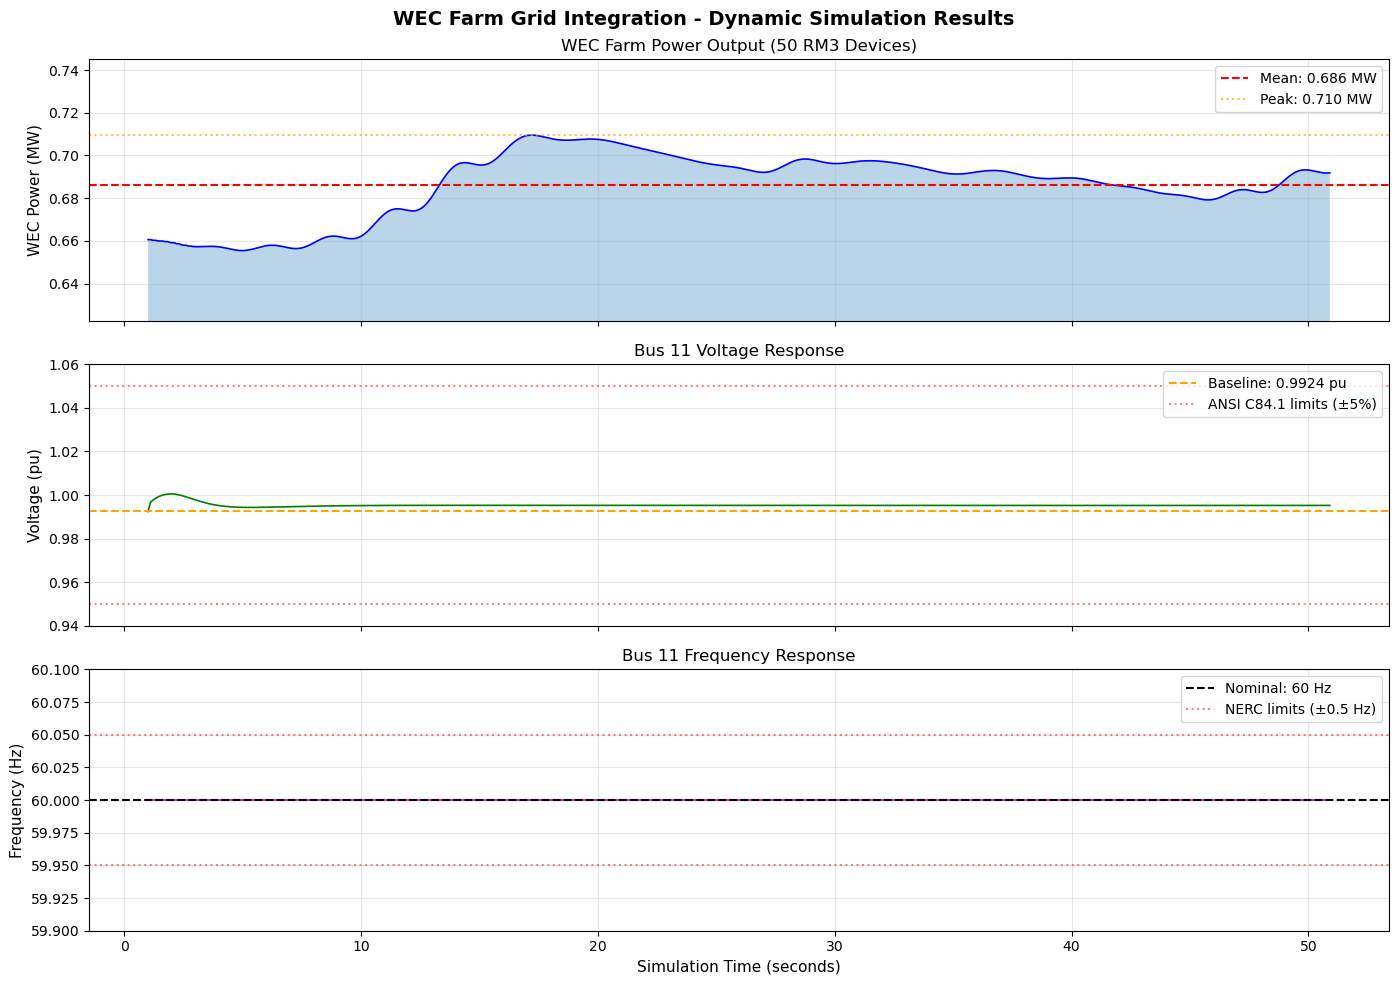


✓ Figure saved to 'wec_dynamic_simulation_results.png'


In [8]:
# === Plot Dynamic Simulation Results ===

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('WEC Farm Grid Integration - Dynamic Simulation Results', fontsize=14, fontweight='bold')

# Plot 1: WEC Power
ax1 = axes[0]
ax1.plot(results_df['time_sec'], results_df['wec_p_mw'], 'b-', linewidth=1.2)
ax1.fill_between(results_df['time_sec'], results_df['wec_p_mw'], alpha=0.3)
ax1.set_ylabel('WEC Power (MW)', fontsize=11)
ax1.set_title(f'WEC Farm Power Output ({NUM_WEC_DEVICES} RM3 Devices)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=results_df['wec_p_mw'].mean(), color='r', linestyle='--', linewidth=1.5,
            label=f"Mean: {results_df['wec_p_mw'].mean():.3f} MW")
ax1.axhline(y=results_df['wec_p_mw'].max(), color='orange', linestyle=':', alpha=0.7,
            label=f"Peak: {results_df['wec_p_mw'].max():.3f} MW")
ax1.legend(loc='upper right')
ax1.set_ylim([results_df['wec_p_mw'].min() * 0.95, results_df['wec_p_mw'].max() * 1.05])

# Plot 2: Bus 11 Voltage
ax2 = axes[1]
ax2.plot(results_df['time_sec'], results_df['bus11_voltage_pu'], 'g-', linewidth=1.2)
ax2.set_ylabel('Voltage (pu)', fontsize=11)
ax2.set_title('Bus 11 Voltage Response', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=v11_baseline, color='orange', linestyle='--', linewidth=1.5,
            label=f'Baseline: {v11_baseline:.4f} pu')
ax2.axhline(y=0.95, color='r', linestyle=':', alpha=0.5, label='ANSI C84.1 limits (±5%)')
ax2.axhline(y=1.05, color='r', linestyle=':', alpha=0.5)
ax2.legend(loc='upper right')
ax2.set_ylim([0.94, 1.06])

# Plot 3: Bus 11 Frequency
ax3 = axes[2]
ax3.plot(results_df['time_sec'], results_df['bus11_freq_hz'], 'm-', linewidth=1.2)
ax3.set_ylabel('Frequency (Hz)', fontsize=11)
ax3.set_xlabel('Simulation Time (seconds)', fontsize=11)
ax3.set_title('Bus 11 Frequency Response', fontsize=12)
ax3.grid(True, alpha=0.3)
ax3.axhline(y=60.0, color='k', linestyle='--', linewidth=1.5, label='Nominal: 60 Hz')
ax3.axhline(y=59.95, color='r', linestyle=':', alpha=0.5, label='NERC limits (±0.5 Hz)')
ax3.axhline(y=60.05, color='r', linestyle=':', alpha=0.5)
ax3.legend(loc='upper right')
ax3.set_ylim([59.9, 60.1])

plt.tight_layout()
plt.savefig('wec_dynamic_simulation_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved to 'wec_dynamic_simulation_results.png'")

---

## 8. Grid Impact Analysis

Quantitative assessment of WEC farm impact on grid voltage and frequency stability.

In [9]:
# === Comprehensive Impact Analysis ===

print("=" * 70)
print("         WEC DYNAMIC SIMULATION - GRID IMPACT ANALYSIS")
print("=" * 70)

# --- WEC Farm Summary ---
print("\n┌─────────────────────────────────────────────────────────────────────┐")
print("│                     WEC FARM CONFIGURATION                          │")
print("├─────────────────────────────────────────────────────────────────────┤")
print(f"│  Device Type:              RM3 Point Absorber                       │")
print(f"│  Number of Devices:        {NUM_WEC_DEVICES:<10}                               │")
print(f"│  Point of Interconnection: Bus {wec_bus:<10}                           │")
print(f"│  Simulation Window:        {results_df['wec_time_sec'].min():.0f}s - {results_df['wec_time_sec'].max():.0f}s (WEC time)           │")
print("└─────────────────────────────────────────────────────────────────────┘")

# --- Power Statistics ---
p_mean = results_df['wec_p_mw'].mean()
p_max = results_df['wec_p_mw'].max()
p_min = results_df['wec_p_mw'].min()
p_std = results_df['wec_p_mw'].std()
p_range = p_max - p_min

print("\n┌─────────────────────────────────────────────────────────────────────┐")
print("│                     POWER OUTPUT STATISTICS                         │")
print("├─────────────────────────────────────────────────────────────────────┤")
print(f"│  Mean Power:               {p_mean:>8.3f} MW                             │")
print(f"│  Peak Power:               {p_max:>8.3f} MW                             │")
print(f"│  Minimum Power:            {p_min:>8.3f} MW                             │")
print(f"│  Standard Deviation:       {p_std:>8.3f} MW                             │")
print(f"│  Power Range (P-P):        {p_range:>8.3f} MW                             │")
print(f"│  Variability (σ/μ):        {(p_std/p_mean)*100:>8.1f} %                              │")
print("└─────────────────────────────────────────────────────────────────────┘")

# --- Voltage Impact ---
v_min = results_df['bus11_voltage_pu'].min()
v_max = results_df['bus11_voltage_pu'].max()
v_mean = results_df['bus11_voltage_pu'].mean()
v_range = v_max - v_min
v_dev_max = max(abs(v_max - v11_baseline), abs(v_min - v11_baseline))
v_dev_pct = v_dev_max / v11_baseline * 100

print("\n┌─────────────────────────────────────────────────────────────────────┐")
print("│                     VOLTAGE IMPACT (Bus 11)                         │")
print("├─────────────────────────────────────────────────────────────────────┤")
print(f"│  Baseline (no WEC):        {v11_baseline:>8.4f} pu                           │")
print(f"│  With WEC - Minimum:       {v_min:>8.4f} pu                           │")
print(f"│  With WEC - Maximum:       {v_max:>8.4f} pu                           │")
print(f"│  With WEC - Mean:          {v_mean:>8.4f} pu                           │")
print(f"│  Voltage Range:            {v_range*1000:>8.2f} mpu                            │")
print(f"│  Max Deviation:            {v_dev_pct:>8.2f} %                              │")
print("├─────────────────────────────────────────────────────────────────────┤")
voltage_status = "✓ PASS" if v_min >= 0.95 and v_max <= 1.05 else "✗ FAIL"
print(f"│  ANSI C84.1 Compliance:    {voltage_status:<15}                        │")
print("└─────────────────────────────────────────────────────────────────────┘")

# --- Frequency Impact ---
f_min = results_df['bus11_freq_hz'].min()
f_max = results_df['bus11_freq_hz'].max()
f_mean = results_df['bus11_freq_hz'].mean()
f_range_mhz = (f_max - f_min) * 1000
f_dev_max = max(abs(f_max - 60.0), abs(f_min - 60.0))

print("\n┌─────────────────────────────────────────────────────────────────────┐")
print("│                    FREQUENCY IMPACT (Bus 11)                        │")
print("├─────────────────────────────────────────────────────────────────────┤")
print(f"│  Nominal:                  {60.0:>8.3f} Hz                             │")
print(f"│  Minimum:                  {f_min:>8.3f} Hz                             │")
print(f"│  Maximum:                  {f_max:>8.3f} Hz                             │")
print(f"│  Mean:                     {f_mean:>8.3f} Hz                             │")
print(f"│  Frequency Range:          {f_range_mhz:>8.1f} mHz                            │")
print(f"│  Max Deviation:            {f_dev_max*1000:>8.1f} mHz                            │")
print("├─────────────────────────────────────────────────────────────────────┤")
freq_status = "✓ PASS" if f_min >= 59.5 and f_max <= 60.5 else "✗ FAIL"
print(f"│  NERC Compliance (±0.5Hz): {freq_status:<15}                        │")
print("└─────────────────────────────────────────────────────────────────────┘")

# --- Correlation Analysis ---
corr_pv = results_df['wec_p_mw'].corr(results_df['bus11_voltage_pu'])
corr_pf = results_df['wec_p_mw'].corr(results_df['bus11_freq_hz'])

print("\n┌─────────────────────────────────────────────────────────────────────┐")
print("│                     CORRELATION ANALYSIS                            │")
print("├─────────────────────────────────────────────────────────────────────┤")
print(f"│  WEC Power ↔ Voltage:      {corr_pv:>8.3f}                              │")
print(f"│  WEC Power ↔ Frequency:    {corr_pf if not np.isnan(corr_pf) else 'N/A':>8}                              │")
print("├─────────────────────────────────────────────────────────────────────┤")
print("│  Interpretation:                                                    │")
if corr_pv < -0.1:
    print("│  • Negative P-V correlation: voltage rises with WEC injection      │")
elif corr_pv > 0.1:
    print("│  • Positive P-V correlation: voltage falls with WEC injection      │")
else:
    print("│  • Weak P-V correlation: voltage largely independent of WEC        │")
print("└─────────────────────────────────────────────────────────────────────┘")

print("\n" + "=" * 70)

         WEC DYNAMIC SIMULATION - GRID IMPACT ANALYSIS

┌─────────────────────────────────────────────────────────────────────┐
│                     WEC FARM CONFIGURATION                          │
├─────────────────────────────────────────────────────────────────────┤
│  Device Type:              RM3 Point Absorber                       │
│  Number of Devices:        50                                       │
│  Point of Interconnection: Bus 11                                   │
│  Simulation Window:        100s - 150s (WEC time)           │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│                     POWER OUTPUT STATISTICS                         │
├─────────────────────────────────────────────────────────────────────┤
│  Mean Power:                  0.686 MW                             │
│  Peak Power:                  0.710 MW                             │
│  Minimum Power:

---

## 9. Additional Visualizations

### Power Spectral Analysis and Time-Domain Correlation

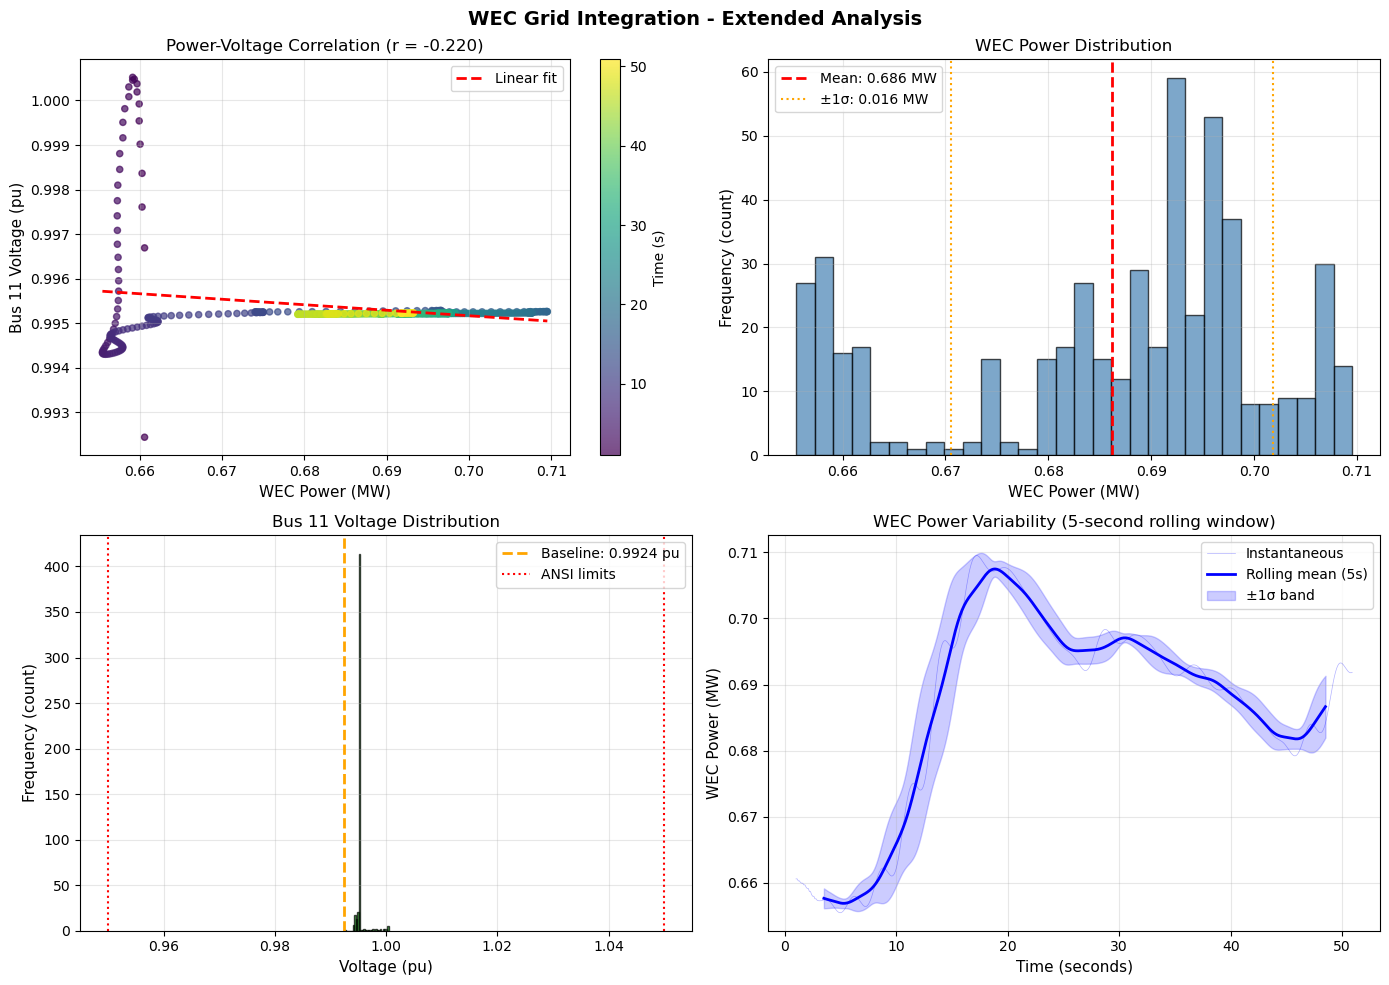


✓ Figure saved to 'wec_extended_analysis.png'


In [10]:
# === Additional Analysis Visualizations ===

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('WEC Grid Integration - Extended Analysis', fontsize=14, fontweight='bold')

# Plot 1: Power vs Voltage Scatter
ax1 = axes[0, 0]
scatter = ax1.scatter(results_df['wec_p_mw'], results_df['bus11_voltage_pu'], 
                      c=results_df['time_sec'], cmap='viridis', alpha=0.7, s=20)
ax1.set_xlabel('WEC Power (MW)', fontsize=11)
ax1.set_ylabel('Bus 11 Voltage (pu)', fontsize=11)
ax1.set_title(f'Power-Voltage Correlation (r = {corr_pv:.3f})', fontsize=12)
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax1, label='Time (s)')

# Add trend line
z = np.polyfit(results_df['wec_p_mw'], results_df['bus11_voltage_pu'], 1)
p = np.poly1d(z)
x_line = np.linspace(results_df['wec_p_mw'].min(), results_df['wec_p_mw'].max(), 100)
ax1.plot(x_line, p(x_line), 'r--', linewidth=2, label='Linear fit')
ax1.legend()

# Plot 2: Power Distribution Histogram
ax2 = axes[0, 1]
ax2.hist(results_df['wec_p_mw'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax2.axvline(x=p_mean, color='r', linestyle='--', linewidth=2, label=f'Mean: {p_mean:.3f} MW')
ax2.axvline(x=p_mean + p_std, color='orange', linestyle=':', linewidth=1.5, label=f'±1σ: {p_std:.3f} MW')
ax2.axvline(x=p_mean - p_std, color='orange', linestyle=':', linewidth=1.5)
ax2.set_xlabel('WEC Power (MW)', fontsize=11)
ax2.set_ylabel('Frequency (count)', fontsize=11)
ax2.set_title('WEC Power Distribution', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Voltage Distribution
ax3 = axes[1, 0]
ax3.hist(results_df['bus11_voltage_pu'], bins=30, color='green', edgecolor='black', alpha=0.7)
ax3.axvline(x=v11_baseline, color='orange', linestyle='--', linewidth=2, label=f'Baseline: {v11_baseline:.4f} pu')
ax3.axvline(x=0.95, color='r', linestyle=':', linewidth=1.5, label='ANSI limits')
ax3.axvline(x=1.05, color='r', linestyle=':', linewidth=1.5)
ax3.set_xlabel('Voltage (pu)', fontsize=11)
ax3.set_ylabel('Frequency (count)', fontsize=11)
ax3.set_title('Bus 11 Voltage Distribution', fontsize=12)
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Rolling Statistics
ax4 = axes[1, 1]
window = 50  # 5-second rolling window
rolling_mean = results_df['wec_p_mw'].rolling(window=window, center=True).mean()
rolling_std = results_df['wec_p_mw'].rolling(window=window, center=True).std()

ax4.plot(results_df['time_sec'], results_df['wec_p_mw'], 'b-', alpha=0.3, linewidth=0.5, label='Instantaneous')
ax4.plot(results_df['time_sec'], rolling_mean, 'b-', linewidth=2, label=f'Rolling mean (5s)')
ax4.fill_between(results_df['time_sec'], 
                 rolling_mean - rolling_std, 
                 rolling_mean + rolling_std, 
                 alpha=0.2, color='blue', label='±1σ band')
ax4.set_xlabel('Time (seconds)', fontsize=11)
ax4.set_ylabel('WEC Power (MW)', fontsize=11)
ax4.set_title('WEC Power Variability (5-second rolling window)', fontsize=12)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('wec_extended_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved to 'wec_extended_analysis.png'")

---

## 10. Discussion and Conclusions

### Key Findings

In [13]:
# === Summary Statistics Table ===

summary_data = {
    'Metric': [
        'WEC Farm Size',
        'Mean Power Output',
        'Power Variability (σ/μ)',
        'Voltage Range',
        'Max Voltage Deviation',
        'Frequency Range',
        'ANSI Voltage Compliance',
        'NERC Frequency Compliance'
    ],
    'Value': [
        f'{NUM_WEC_DEVICES} devices',
        f'{p_mean:.3f} MW',
        f'{(p_std/p_mean)*100:.1f}%',
        f'{v_range*1000:.2f} mpu',
        f'{v_dev_pct:.2f}%',
        f'{f_range_mhz:.1f} mHz',
        '✓ Pass' if v_min >= 0.95 and v_max <= 1.05 else '✗ Fail',
        '✓ Pass' if f_min >= 59.5 and f_max <= 60.5 else '✗ Fail'
    ],
    'Notes': [
        'RM3 point absorbers',
        'Scaled farm output',
        'Coefficient of variation',
        'Peak-to-peak',
        'From baseline',
        'Peak-to-peak',
        '0.95 ≤ V ≤ 1.05 pu',
        '59.5 ≤ f ≤ 60.5 Hz'
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "=" * 70)
print("                    SIMULATION RESULTS SUMMARY")
print("=" * 70)
print(summary_df.to_string(index=False))
print("=" * 70)

# Interpretation
print("\n### Interpretation\n")

print("**Voltage Response:**")
if v_dev_pct < 1.0:
    print(f"  The WEC farm causes minimal voltage impact ({v_dev_pct:.2f}% max deviation).")
    print("  The grid is stiff enough to absorb the power variations without")
    print("  significant voltage fluctuations.")
else:
    print(f"  The WEC farm causes notable voltage variation ({v_dev_pct:.2f}% deviation).")
    print("  Voltage regulation or reactive power compensation may be needed.")

print("\n**Frequency Response:**")
if f_range_mhz < 10:
    print(f"  Frequency remains essentially constant ({f_range_mhz:.1f} mHz range).")
    print("  This indicates:")
    print("    • High system inertia relative to WEC power variations")
    print("    • Fast governor response maintaining frequency stability")
    print("    • WEC power magnitude is small relative to total system generation")
else:
    print(f"  Measurable frequency variation observed ({f_range_mhz:.1f} mHz range).")
    print("  The system shows dynamic response to WEC power fluctuations.")

print("\n**Power-Voltage Correlation:**")
print(f"  Correlation coefficient: {corr_pv:.3f}")
if corr_pv < -0.1:
    print("  Negative correlation indicates voltage rises when WEC injects more power,")
    print("  consistent with reduced net load at the injection bus.")
elif abs(corr_pv) < 0.1:
    print("  Weak correlation suggests voltage is dominated by other system factors.")

print("\n" + "=" * 70)


                    SIMULATION RESULTS SUMMARY
                   Metric      Value                    Notes
            WEC Farm Size 50 devices      RM3 point absorbers
        Mean Power Output   0.686 MW       Scaled farm output
  Power Variability (σ/μ)       2.3% Coefficient of variation
            Voltage Range   8.08 mpu             Peak-to-peak
    Max Voltage Deviation      0.81%            From baseline
          Frequency Range    0.0 mHz             Peak-to-peak
  ANSI Voltage Compliance     ✓ Pass       0.95 ≤ V ≤ 1.05 pu
NERC Frequency Compliance     ✓ Pass       59.5 ≤ f ≤ 60.5 Hz

### Interpretation

**Voltage Response:**
  The WEC farm causes minimal voltage impact (0.81% max deviation).
  The grid is stiff enough to absorb the power variations without
  significant voltage fluctuations.

**Frequency Response:**
  Frequency remains essentially constant (0.0 mHz range).
  This indicates:
    • High system inertia relative to WEC power variations
    • Fast governor r

---

## 11. Methodology Notes

### Limitations and Assumptions

1. **Single Point of Interconnection:** All WEC power injected at Bus 11. Real offshore farms may connect via multiple feeders.

2. **Aggregated Power Profile:** Individual device outputs summed directly. In practice, spatial separation causes partial smoothing of aggregate output.

3. **Reduced Inertia Model:** IEEE 14-bus modified for sensitivity. Results may differ from actual grid conditions.

4. **No Energy Storage:** Direct injection without smoothing. Battery or flywheel systems would reduce variability.

5. **Unity Power Factor:** Only active power (P) injected. Reactive power (Q) support could improve voltage stability.

### Future Work

- Investigate larger WEC farm sizes (100-500 devices)
- Add energy storage models for power smoothing
- Study frequency response with further reduced inertia
- Compare multiple interconnection strategies
- Include cable/transformer impedance models

### References

1. NREL Co-Simulation Framework: https://docs.nrel.gov/docs/fy25osti/91114.pdf
2. WEC-Sim: https://wec-sim.github.io/WEC-Sim/
3. IEEE 14-Bus Test Case: https://icseg.iti.illinois.edu/ieee-14-bus-system/

---

## 12. Export Results

Save simulation results for external analysis or reporting.

In [ ]:
# === Export Simulation Results ===

# Save time-series data to CSV
output_csv = 'wec_dynamic_simulation_results.csv'
results_df.to_csv(output_csv, index=False)
print(f"✓ Time-series data saved to '{output_csv}'")

# Save summary statistics to CSV
summary_df.to_csv('wec_simulation_summary.csv', index=False)
print(f"✓ Summary statistics saved to 'wec_simulation_summary.csv'")

# Display final file list
print("\n" + "=" * 50)
print("OUTPUT FILES GENERATED:")
print("=" * 50)
print("  📊 wec_dynamic_simulation_results.csv  - Time-series data")
print("  📈 wec_simulation_summary.csv          - Summary statistics")
print("  🖼️  wec_dynamic_simulation_results.png - Main results figure")
print("  🖼️  wec_extended_analysis.png          - Extended analysis figure")
print("=" * 50)